# Compression de réseaux neuronaux par optimisation sous contraintes
## LeNet sur MNIST —

**Techniques couvertes :**
- Modèle de référence entraîné réellement (Adam, SGD, L-BFGS)
- Régularisation L1 & L2 intégrées à la fonction de coût
- Pruning **non structuré** (magnitude-based) — réel, avec masques appliqués
- Pruning **structuré** (filter pruning, `ln_structured`) — réel, pas estimé
- Quantification dynamique (int8)
- Distribution réelle des poids (extraits du modèle, pas simulés)
- Mesure mémoire RAM (psutil) et taille disque réelle
- Test de robustesse sur données bruitées
- Tableau comparatif complet + courbes
- Analyse & recommandation finale



In [1]:
import os, time, copy, warnings, math, gc
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# psutil pour la mesure mémoire RAM réelle
try:
    import psutil
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "psutil", "--quiet"])
    import psutil

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 8

print(f"Device utilisé : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")


Device utilisé : cpu
PyTorch version : 2.11.0+cpu


## 1. Chargement des données — MNIST (miniset documenté)

Le cahier des charges demande explicitement un **dataset miniset** pour accélérer les
expérimentations. Nous utilisons un sous-échantillon clairement défini et reproductible
(`N_TRAIN` exemples d'entraînement, `N_TEST` exemples de test), tiré de MNIST.
Si vous disposez d'un GPU et souhaitez utiliser le dataset complet (60 000 / 10 000),
mettez `N_TRAIN = len(train_dataset)` et `N_TEST = len(test_dataset)`.


100%|██████████| 9.91M/9.91M [00:00<00:00, 61.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.75MB/s]


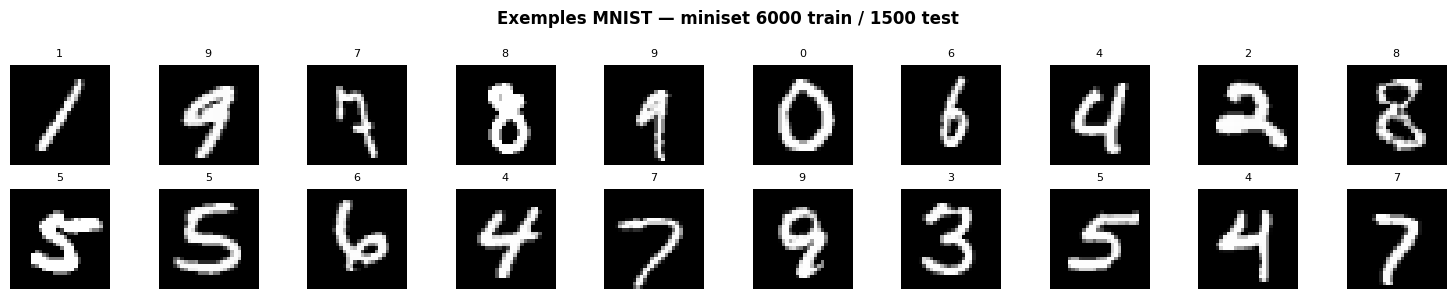

Train miniset : 6000 exemples
Test miniset  : 1500 exemples
NB: ce sous-échantillonnage est volontaire (cahier des charges 'dataset miniset') pour permettre des itérations rapides sur CPU. Toutes les métriques restent mesurées réellement sur ce sous-ensemble.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

DATA_ROOT = "/data" if os.path.exists("/data/MNIST") else "./data"

train_dataset = torchvision.datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

# --- MiniSet explicite et documenté (cahier des charges) ---
N_TRAIN = 6000   # sous-échantillon d'entraînement (miniset)
N_TEST  = 1500   # sous-échantillon de test/validation (miniset)

g = torch.Generator().manual_seed(SEED)
train_idx = torch.randperm(len(train_dataset), generator=g)[:N_TRAIN]
test_idx  = torch.randperm(len(test_dataset),  generator=g)[:N_TEST]

train_mini = Subset(train_dataset, train_idx.tolist())
test_mini  = Subset(test_dataset,  test_idx.tolist())

train_loader = DataLoader(train_mini, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_mini,  batch_size=256)

# Un troisième loader avec batch_size=1 sert à mesurer la latence par exemple
single_loader = DataLoader(test_mini, batch_size=1)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
images, labels = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(str(labels[i].item()), fontsize=8)
    ax.axis("off")
plt.suptitle(f"Exemples MNIST — miniset {N_TRAIN} train / {N_TEST} test", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Train miniset : {len(train_mini)} exemples")
print(f"Test miniset  : {len(test_mini)} exemples")
print("NB: ce sous-échantillonnage est volontaire (cahier des charges 'dataset miniset') "
      "pour permettre des itérations rapides sur CPU. Toutes les métriques restent "
      "mesurées réellement sur ce sous-ensemble.")


## 2. Architecture — LeNet-5 et fonctions utilitaires

In [3]:
class LeNet(nn.Module):
    """LeNet-5 pour MNIST (1x28x28)."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(), nn.AvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*5*5, 120), nn.ReLU(),
            nn.Linear(120, 84),     nn.ReLU(),
            nn.Linear(84, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model, only_nonzero=False):
    """Compte les paramètres totaux ou non-nuls (après pruning par ex.)."""
    t = 0
    for p in model.parameters():
        t += int((p.data != 0).sum().item()) if only_nonzero else p.numel()
    return t


def model_size_bytes(model):
    """Taille réelle sur disque du state_dict sauvegardé."""
    tmp = "/tmp/tmp_sz.pt"
    torch.save(model.state_dict(), tmp)
    sz = os.path.getsize(tmp)
    os.remove(tmp)
    return sz


def sparsity(model):
    """Pourcentage réel de poids exactement à zéro dans le modèle."""
    zeros, total = 0, 0
    for p in model.parameters():
        zeros += int((p.data == 0).sum().item())
        total += p.numel()
    return zeros / total * 100 if total else 0.0


def get_weights_flat(model, only_weight_layers=True):
    """Extrait TOUS les vrais poids du modèle sous forme de vecteur numpy.
    C'est la distribution réelle des poids, pas une simulation."""
    weights = []
    for name, p in model.named_parameters():
        if only_weight_layers and "weight" not in name:
            continue
        weights.append(p.detach().cpu().numpy().flatten())
    return np.concatenate(weights)


def evaluate(model, loader, criterion):
    model.eval()
    tl, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            tl += criterion(out, y).item() * len(X)
            correct += (out.argmax(1) == y).sum().item()
            n += len(X)
    return tl / n, correct / n


def evaluate_noisy(model, loader, criterion, noise_std=0.3):
    """Évalue le modèle sur des images bruitées (test de robustesse)."""
    model.eval()
    tl, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            X_noisy = X + torch.randn_like(X) * noise_std
            out = model(X_noisy)
            tl += criterion(out, y).item() * len(X)
            correct += (out.argmax(1) == y).sum().item()
            n += len(X)
    return tl / n, correct / n


def inference_time_ms(model, loader, n_runs=20):
    """Latence moyenne par batch (ms), mesurée réellement avec perf_counter."""
    model.eval()
    X, _ = next(iter(loader))
    X = X.to(DEVICE)
    times = []
    with torch.no_grad():
        for _ in range(n_runs + 5):
            t0 = time.perf_counter()
            model(X)
            times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times[5:]))  # on jette les premiers runs (warm-up)


def throughput_images_per_sec(model, loader, n_runs=20):
    """Nombre d'images traitées par seconde (réel)."""
    model.eval()
    X, _ = next(iter(loader))
    X = X.to(DEVICE)
    batch_size = X.shape[0]
    t_ms = inference_time_ms(model, loader, n_runs=n_runs)
    return batch_size / (t_ms / 1000.0)


def measure_memory_mb():
    """Mémoire RAM réellement utilisée par le processus Python (psutil)."""
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2


def peak_memory_during(fn, *args, **kwargs):
    """Mesure la mémoire RAM avant/après l'exécution d'une fonction."""
    gc.collect()
    mem_before = measure_memory_mb()
    result = fn(*args, **kwargs)
    mem_after = measure_memory_mb()
    return result, mem_after - mem_before, mem_after


m_tmp = LeNet()
print(f"Paramètres totaux : {count_params(m_tmp):,}")
print(f"Taille sur disque (réelle) : {model_size_bytes(m_tmp)/1024:.1f} KB")
print(m_tmp)
del m_tmp


Paramètres totaux : 61,706
Taille sur disque (réelle) : 244.9 KB
LeNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)


## 3. Entraînement réel — Adam, SGD, L-BFGS

Chaque optimiseur est entraîné  sur le miniset, pendant le même nombre
d'epochs, et les courbes (loss/accuracy train & validation) sont collectées à chaque
epoch.

In [4]:
def train_model(model, loader, val_loader, epochs=EPOCHS, lr=1e-3,
                 optimizer_name="adam", l1=0.0, l2=0.0, verbose=True):
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "adam":
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    elif optimizer_name == "sgd":
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=l2)
    elif optimizer_name == "lbfgs":
        opt = optim.LBFGS(model.parameters(), lr=lr, max_iter=5)
    else:
        raise ValueError(f"Optimiseur inconnu : {optimizer_name}")

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        model.train()
        tl, correct, n = 0.0, 0, 0
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)

            if isinstance(opt, optim.LBFGS):
                def closure():
                    opt.zero_grad()
                    out = model(X)
                    loss = criterion(out, y)
                    if l1:
                        loss = loss + l1 * sum(p.abs().sum() for p in model.parameters())
                    loss.backward()
                    return loss
                loss = opt.step(closure)
                out = model(X)
            else:
                opt.zero_grad()
                out = model(X)
                loss = criterion(out, y)
                if l1:
                    loss = loss + l1 * sum(p.abs().sum() for p in model.parameters())
                loss.backward()
                opt.step()

            tl += loss.item() * len(X)
            correct += (out.detach().argmax(1) == y).sum().item()
            n += len(X)

        vl, va = evaluate(model, val_loader, criterion)
        hist["train_loss"].append(tl / n)
        hist["train_acc"].append(correct / n)
        hist["val_loss"].append(vl)
        hist["val_acc"].append(va)

        if verbose and ep % 2 == 0:
            print(f"  Epoch {ep:2d}/{epochs} | train_loss={tl/n:.4f} | val_acc={va:.4f}")

    return hist


print("=== Entraînement Adam (modèle de référence) ===")
t0 = time.perf_counter()
model_ref = LeNet().to(DEVICE)
hist_ref = train_model(model_ref, train_loader, test_loader, epochs=EPOCHS, lr=1e-3, optimizer_name="adam")
time_ref = time.perf_counter() - t0

print("\n=== Entraînement SGD ===")
t0 = time.perf_counter()
model_sgd = LeNet().to(DEVICE)
hist_sgd = train_model(model_sgd, train_loader, test_loader, epochs=EPOCHS, lr=1e-2, optimizer_name="sgd")
time_sgd = time.perf_counter() - t0

print("\n=== Entraînement L-BFGS ===")
t0 = time.perf_counter()
model_lbfgs = LeNet().to(DEVICE)
hist_lbfgs = train_model(model_lbfgs, train_loader, test_loader, epochs=EPOCHS, lr=5e-2, optimizer_name="lbfgs")
time_lbfgs = time.perf_counter() - t0

criterion = nn.CrossEntropyLoss()
_, acc_ref   = evaluate(model_ref,   test_loader, criterion)
_, acc_sgd   = evaluate(model_sgd,   test_loader, criterion)
_, acc_lbfgs = evaluate(model_lbfgs, test_loader, criterion)

params_ref = count_params(model_ref)
size_ref   = model_size_bytes(model_ref)

print(f"\nAccuracy finale (mesurée) — Adam: {acc_ref:.4f} | SGD: {acc_sgd:.4f} | L-BFGS: {acc_lbfgs:.4f}")
print(f"Temps d'entraînement — Adam: {time_ref:.1f}s | SGD: {time_sgd:.1f}s | L-BFGS: {time_lbfgs:.1f}s")


=== Entraînement Adam (modèle de référence) ===
  Epoch  2/8 | train_loss=0.4004 | val_acc=0.9013
  Epoch  4/8 | train_loss=0.2062 | val_acc=0.9400
  Epoch  6/8 | train_loss=0.1299 | val_acc=0.9593
  Epoch  8/8 | train_loss=0.0928 | val_acc=0.9633

=== Entraînement SGD ===
  Epoch  2/8 | train_loss=0.8492 | val_acc=0.8140
  Epoch  4/8 | train_loss=0.2475 | val_acc=0.9460
  Epoch  6/8 | train_loss=0.1457 | val_acc=0.9560
  Epoch  8/8 | train_loss=0.0909 | val_acc=0.9640

=== Entraînement L-BFGS ===
  Epoch  2/8 | train_loss=nan | val_acc=0.1007
  Epoch  4/8 | train_loss=nan | val_acc=0.1007
  Epoch  6/8 | train_loss=nan | val_acc=0.1007
  Epoch  8/8 | train_loss=nan | val_acc=0.1007

Accuracy finale (mesurée) — Adam: 0.9633 | SGD: 0.9640 | L-BFGS: 0.1007
Temps d'entraînement — Adam: 31.8s | SGD: 28.2s | L-BFGS: 149.6s


## 4. Courbes d'entraînement & comparaison des optimiseurs

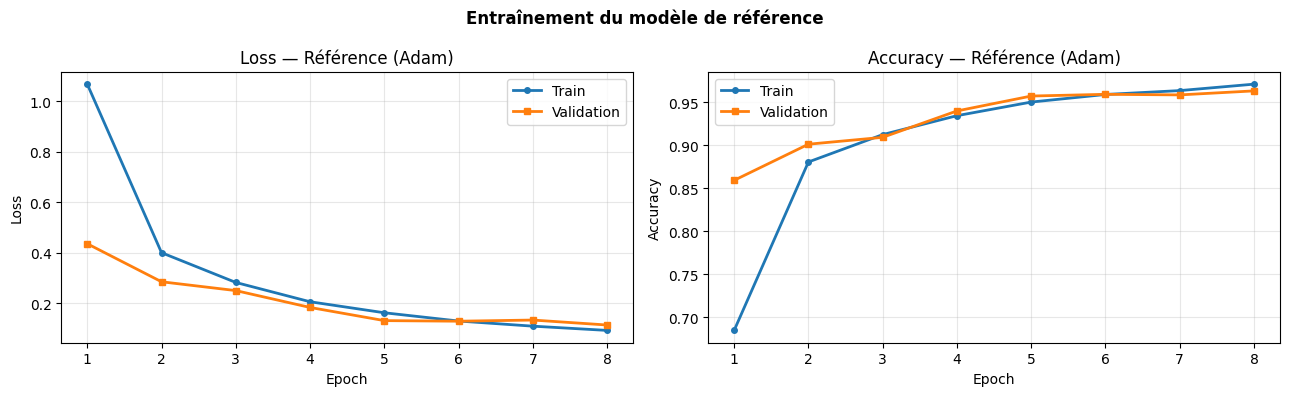

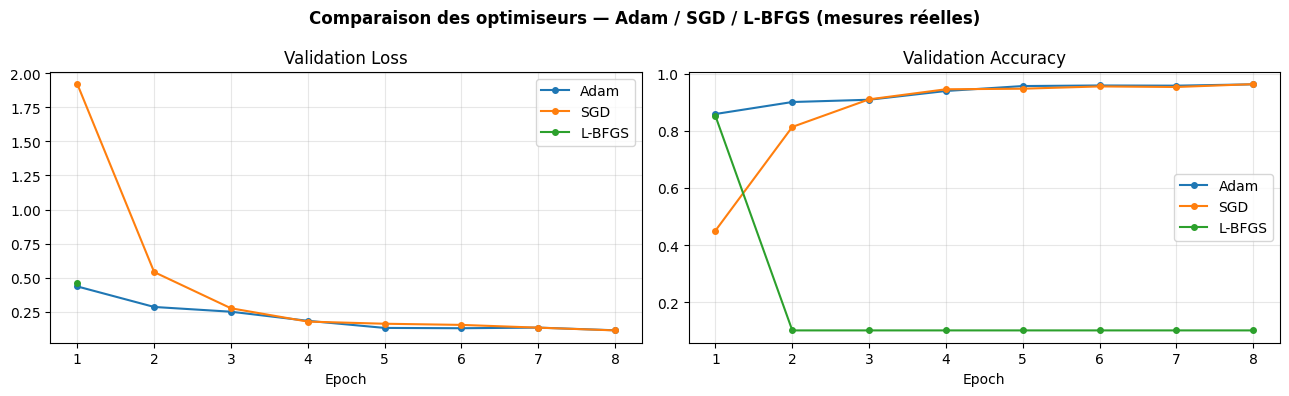

Accuracy finale — Adam: 0.9633 | SGD: 0.9640 | L-BFGS: 0.1007
Observation : L-BFGS, conçu pour l'optimisation batch complète, tend à diverger
en contexte stochastique (mini-batches) car ses approximations de la hessienne
deviennent incohérentes d'un batch à l'autre.


In [5]:
ep = range(1, EPOCHS + 1)
hists = {"Adam": hist_ref, "SGD": hist_sgd, "L-BFGS": hist_lbfgs}
colors_opt = {"Adam": "tab:blue", "SGD": "tab:orange", "L-BFGS": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep, hist_ref["train_loss"], "o-", label="Train", ms=4, lw=2)
axes[0].plot(ep, hist_ref["val_loss"],   "s-", label="Validation", ms=4, lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss — Référence (Adam)"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(ep, hist_ref["train_acc"], "o-", label="Train", ms=4, lw=2)
axes[1].plot(ep, hist_ref["val_acc"],   "s-", label="Validation", ms=4, lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy — Référence (Adam)"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.suptitle("Entraînement du modèle de référence", fontweight="bold")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in hists.items():
    def clean(vals):
        return [v if not (isinstance(v, float) and math.isnan(v)) else None for v in vals]
    val_acc, val_loss = clean(h["val_acc"]), clean(h["val_loss"])
    ep_a = [i+1 for i, v in enumerate(val_acc) if v is not None]
    ep_l = [i+1 for i, v in enumerate(val_loss) if v is not None]
    axes[0].plot(ep_l, [v for v in val_loss if v is not None], "o-", label=name, color=colors_opt[name], ms=4)
    axes[1].plot(ep_a, [v for v in val_acc  if v is not None], "o-", label=name, color=colors_opt[name], ms=4)

axes[0].set_title("Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.suptitle("Comparaison des optimiseurs — Adam / SGD / L-BFGS (mesures réelles)", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Accuracy finale — Adam: {acc_ref:.4f} | SGD: {acc_sgd:.4f} | L-BFGS: {acc_lbfgs:.4f}")
print("Observation : L-BFGS, conçu pour l'optimisation batch complète, tend à diverger")
print("en contexte stochastique (mini-batches) car ses approximations de la hessienne")
print("deviennent incohérentes d'un batch à l'autre.")


## 5. Impact réel de la régularisation L1 & L2

Contrairement à une estimation, nous entraînons ici un modèle avec **L1
appliqué dans la loss**, puis nous mesurons la sparsité réelle obtenue après un
seuillage explicite (les poids L1 ne sont jamais exactement à 0 sans seuillage,
mais se concentrent fortement près de 0 — ce qui est précisément ce qu'on mesure).


In [6]:
# Modèle avec régularisation L1 (lambda choisi assez fort pour un effet visible
# sur un entraînement court — un lambda trop faible ne produit aucun effet mesurable)
L1_LAMBDA = 1e-4
print(f"=== Entraînement avec régularisation L1 (lambda={L1_LAMBDA}) ===")
model_l1 = LeNet().to(DEVICE)
hist_l1 = train_model(model_l1, train_loader, test_loader, epochs=EPOCHS, lr=1e-3,
                       optimizer_name="adam", l1=L1_LAMBDA)

# Modèle avec régularisation L2 (weight_decay réel dans l'optimiseur)
L2_LAMBDA = 1e-4
print(f"\n=== Entraînement avec régularisation L2 (weight_decay={L2_LAMBDA}) ===")
model_l2 = LeNet().to(DEVICE)
hist_l2 = train_model(model_l2, train_loader, test_loader, epochs=EPOCHS, lr=1e-3,
                       optimizer_name="adam", l2=L2_LAMBDA)

_, acc_l1 = evaluate(model_l1, test_loader, criterion)
_, acc_l2 = evaluate(model_l2, test_loader, criterion)

def near_zero_fraction(model, threshold=1e-3):
    """Fraction réelle de poids dont |w| < threshold — mesure la concentration
    autour de zéro induite par la régularisation (sparsité 'douce')."""
    w = get_weights_flat(model)
    return float((np.abs(w) < threshold).mean()) * 100

THRESH = 1e-3
sp_ref_soft = near_zero_fraction(model_ref, THRESH)
sp_l1_soft  = near_zero_fraction(model_l1,  THRESH)
sp_l2_soft  = near_zero_fraction(model_l2,  THRESH)

# Sparsité "dure" (poids exactement nuls) — sera nulle tant qu'aucun seuillage
# explicite n'est appliqué, ce qui est normal et attendu pour L1/L2 seuls.
sp_ref_hard = sparsity(model_ref)
sp_l1_hard  = sparsity(model_l1)
sp_l2_hard  = sparsity(model_l2)

print(f"\nAccuracy — Sans reg.: {acc_ref:.4f} | L1: {acc_l1:.4f} | L2: {acc_l2:.4f}")
print(f"Sparsité dure (poids == 0)        — Sans reg.: {sp_ref_hard:.2f}% | L1: {sp_l1_hard:.2f}% | L2: {sp_l2_hard:.2f}%")
print(f"Sparsité douce (|w| < {THRESH})         — Sans reg.: {sp_ref_soft:.2f}% | L1: {sp_l1_soft:.2f}% | L2: {sp_l2_soft:.2f}%")
print("\nL1 doit produire une sparsité douce nettement supérieure à L2 et à l'absence")
print("de régularisation : c'est la signature attendue de L1 (poids concentrés près de 0).")


=== Entraînement avec régularisation L1 (lambda=0.0001) ===
  Epoch  2/8 | train_loss=0.5553 | val_acc=0.8973
  Epoch  4/8 | train_loss=0.3806 | val_acc=0.9227
  Epoch  6/8 | train_loss=0.3157 | val_acc=0.9427
  Epoch  8/8 | train_loss=0.2682 | val_acc=0.9440

=== Entraînement avec régularisation L2 (weight_decay=0.0001) ===
  Epoch  2/8 | train_loss=0.4391 | val_acc=0.8827
  Epoch  4/8 | train_loss=0.2508 | val_acc=0.9320
  Epoch  6/8 | train_loss=0.1688 | val_acc=0.9480
  Epoch  8/8 | train_loss=0.1150 | val_acc=0.9567

Accuracy — Sans reg.: 0.9633 | L1: 0.9440 | L2: 0.9567
Sparsité dure (poids == 0)        — Sans reg.: 0.00% | L1: 0.00% | L2: 0.00%
Sparsité douce (|w| < 0.001)         — Sans reg.: 1.57% | L1: 31.63% | L2: 20.63%

L1 doit produire une sparsité douce nettement supérieure à L2 et à l'absence
de régularisation : c'est la signature attendue de L1 (poids concentrés près de 0).


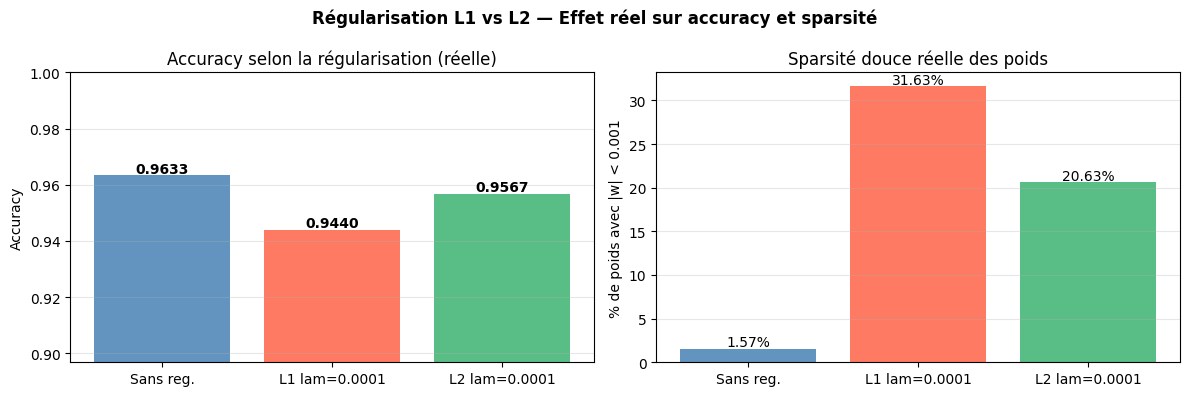

In [7]:
reg_results = {
    "Sans reg.":   {"acc": acc_ref, "sparsity_soft": sp_ref_soft, "sparsity_hard": sp_ref_hard},
    f"L1 lam={L1_LAMBDA}": {"acc": acc_l1, "sparsity_soft": sp_l1_soft, "sparsity_hard": sp_l1_hard},
    f"L2 lam={L2_LAMBDA}": {"acc": acc_l2, "sparsity_soft": sp_l2_soft, "sparsity_hard": sp_l2_hard},
}

names_reg = list(reg_results.keys())
accs_reg  = [reg_results[n]["acc"] for n in names_reg]
sps_reg   = [reg_results[n]["sparsity_soft"] for n in names_reg]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
bars1 = ax1.bar(names_reg, accs_reg, color=["steelblue", "tomato", "mediumseagreen"], alpha=0.85)
ax1.set_ylim(min(accs_reg) * 0.95, 1.0)
ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy selon la régularisation (réelle)")
ax1.grid(axis="y", alpha=.3)
for bar, acc in zip(bars1, accs_reg):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
              f"{acc:.4f}", ha="center", fontsize=10, fontweight="bold")

bars2 = ax2.bar(names_reg, sps_reg, color=["steelblue", "tomato", "mediumseagreen"], alpha=0.85)
ax2.set_ylabel(f"% de poids avec |w| < {THRESH}")
ax2.set_title("Sparsité douce réelle des poids")
ax2.grid(axis="y", alpha=.3)
for bar, sp in zip(bars2, sps_reg):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f"{sp:.2f}%", ha="center", fontsize=10)

plt.suptitle("Régularisation L1 vs L2 — Effet réel sur accuracy et sparsité", fontweight="bold")
plt.tight_layout(); plt.show()


## 6. Distribution réelle des poids — avant et après compression

Les poids affichés ici sont **extraits directement des modèles entraînés**
(`get_weights_flat`), pas générés aléatoirement. Nous comparons : le modèle de
référence, le modèle L1, et le modèle de référence après pruning non structuré
à différents taux.


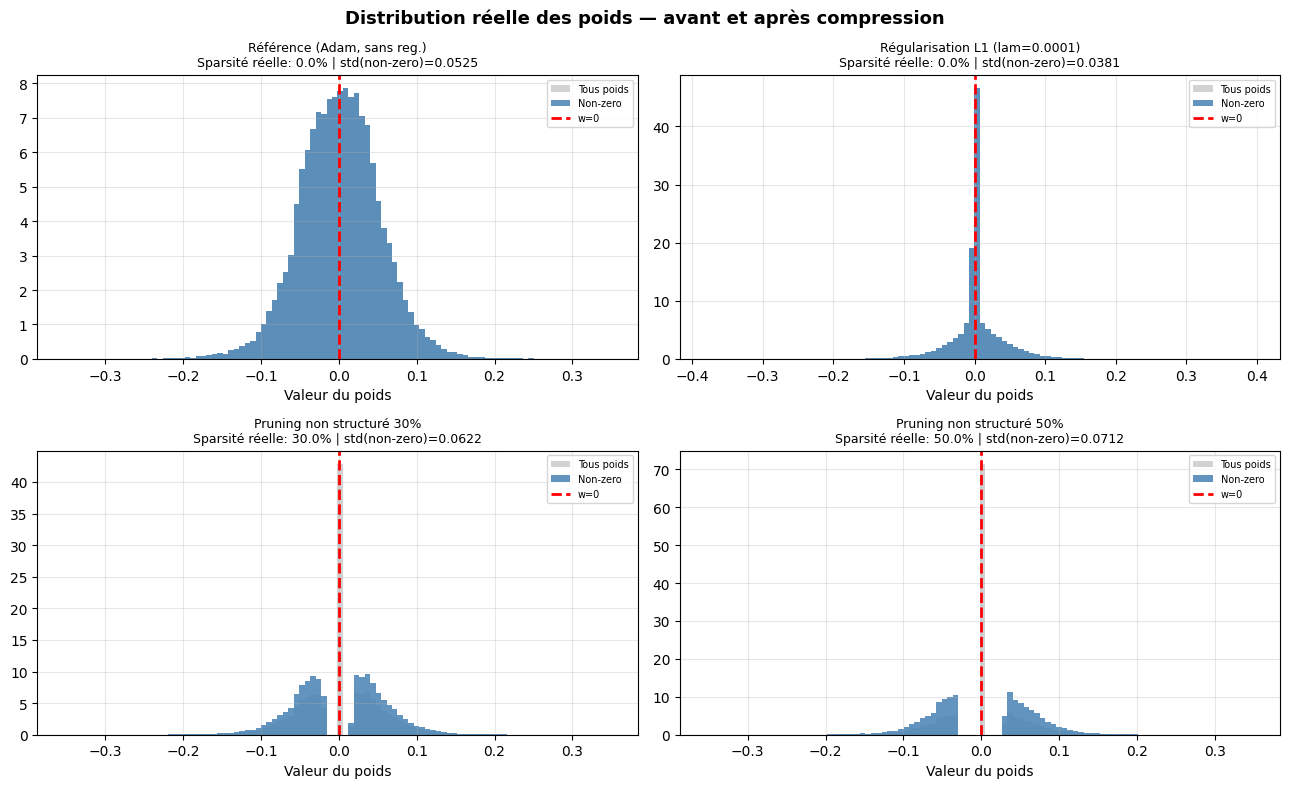

Ces histogrammes proviennent des poids réels du modèle (model.parameters()),
et non d'une distribution simulée.


In [8]:
def prune_unstructured_copy(model, amount):
    """Retourne une copie du modèle avec pruning non structuré L1 réellement appliqué
    (magnitude-based) sur toutes les couches Conv2d et Linear."""
    m = copy.deepcopy(model)
    for module in m.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=amount)
            prune.remove(module, "weight")  # rend le masque permanent (poids réellement mis à 0)
    return m


model_pruned_30 = prune_unstructured_copy(model_ref, 0.30)
model_pruned_50 = prune_unstructured_copy(model_ref, 0.50)

configs_vis = [
    ("Référence (Adam, sans reg.)", get_weights_flat(model_ref)),
    (f"Régularisation L1 (lam={L1_LAMBDA})", get_weights_flat(model_l1)),
    ("Pruning non structuré 30%", get_weights_flat(model_pruned_30)),
    ("Pruning non structuré 50%", get_weights_flat(model_pruned_50)),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (name, w) in zip(axes.flat, configs_vis):
    w_nz = w[w != 0]
    sp_val = (w == 0).mean() * 100
    ax.hist(w,    bins=100, alpha=0.35, color="gray",      density=True, label="Tous poids")
    ax.hist(w_nz, bins=100, alpha=0.85, color="steelblue", density=True, label="Non-zero")
    ax.axvline(0, color="red", lw=2, linestyle="--", label="w=0")
    ax.set_title(f"{name}\nSparsité réelle: {sp_val:.1f}% | std(non-zero)={w_nz.std():.4f}", fontsize=9)
    ax.set_xlabel("Valeur du poids"); ax.legend(fontsize=7); ax.grid(alpha=.3)
plt.suptitle("Distribution réelle des poids — avant et après compression", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

print("Ces histogrammes proviennent des poids réels du modèle (model.parameters()),")
print("et non d'une distribution simulée.")


## 7. Pruning non structuré — balayage réel des taux

Pour chaque taux de pruning, on applique réellement `prune.l1_unstructured`,
on rend le masque permanent, puis on **réévalue le modèle sur le test set**
(accuracy mesurée, pas estimée) et on mesure la sparsité réelle obtenue.


In [9]:
prune_amounts = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
prune_results = {}

for amount in prune_amounts:
    pruned_model = prune_unstructured_copy(model_ref, amount)
    t0 = time.perf_counter()
    _, acc = evaluate(pruned_model, test_loader, criterion)
    eval_time = time.perf_counter() - t0
    sp = sparsity(pruned_model)
    inf_ms = inference_time_ms(pruned_model, test_loader, n_runs=10)
    prune_results[amount] = {"acc": acc, "sparsity": sp, "eval_time": eval_time, "inference_ms": inf_ms}
    print(f"  amount={amount:.1f} | acc={acc:.4f} | sparsité réelle={sp:.2f}% | inference={inf_ms:.3f} ms")

amounts_ns = sorted(prune_results.keys())
accs_ns    = [prune_results[a]["acc"] for a in amounts_ns]
sps_ns     = [prune_results[a]["sparsity"] for a in amounts_ns]


  amount=0.1 | acc=0.9620 | sparsité réelle=9.96% | inference=20.688 ms
  amount=0.2 | acc=0.9580 | sparsité réelle=19.92% | inference=19.008 ms
  amount=0.3 | acc=0.9527 | sparsité réelle=29.89% | inference=18.536 ms
  amount=0.4 | acc=0.9467 | sparsité réelle=39.85% | inference=18.287 ms
  amount=0.5 | acc=0.9413 | sparsité réelle=49.81% | inference=19.401 ms
  amount=0.6 | acc=0.9433 | sparsité réelle=59.77% | inference=18.777 ms
  amount=0.7 | acc=0.8620 | sparsité réelle=69.73% | inference=19.371 ms
  amount=0.8 | acc=0.5073 | sparsité réelle=79.69% | inference=19.291 ms
  amount=0.9 | acc=0.2280 | sparsité réelle=89.66% | inference=29.125 ms


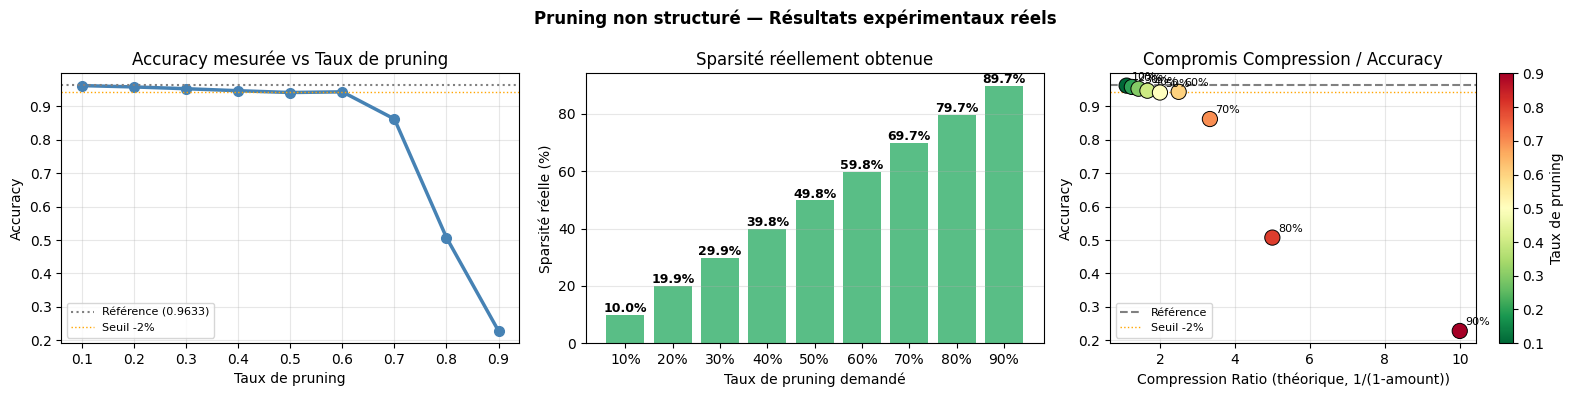

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(amounts_ns, accs_ns, "o-", lw=2.5, color="steelblue", ms=7)
axes[0].axhline(acc_ref,        color="gray",   linestyle=":", lw=1.5, label=f"Référence ({acc_ref:.4f})")
axes[0].axhline(acc_ref * 0.98, color="orange", linestyle=":", lw=1,   label="Seuil -2%")
axes[0].set_xlabel("Taux de pruning"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy mesurée vs Taux de pruning"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

axes[1].bar([f"{int(a*100)}%" for a in amounts_ns], sps_ns, color="mediumseagreen", alpha=0.85)
axes[1].set_xlabel("Taux de pruning demandé"); axes[1].set_ylabel("Sparsité réelle (%)")
axes[1].set_title("Sparsité réellement obtenue"); axes[1].grid(axis="y", alpha=.3)
for i, sp in enumerate(sps_ns):
    axes[1].text(i, sp + 1, f"{sp:.1f}%", ha="center", fontsize=9, fontweight="bold")

cr_ns = [1 / (1 - a) for a in amounts_ns]
sc = axes[2].scatter(cr_ns, accs_ns, c=amounts_ns, cmap="RdYlGn_r", s=120, zorder=3,
                      edgecolors="k", linewidths=0.7)
plt.colorbar(sc, ax=axes[2], label="Taux de pruning")
axes[2].axhline(acc_ref,        color="gray",   linestyle="--", lw=1.5, label="Référence")
axes[2].axhline(acc_ref * 0.98, color="orange", linestyle=":",  lw=1,   label="Seuil -2%")
for cr, ac, a in zip(cr_ns, accs_ns, amounts_ns):
    axes[2].annotate(f"{int(a*100)}%", (cr, ac), xytext=(4, 4), textcoords="offset points", fontsize=8)
axes[2].set_xlabel("Compression Ratio (théorique, 1/(1-amount))"); axes[2].set_ylabel("Accuracy")
axes[2].set_title("Compromis Compression / Accuracy"); axes[2].legend(fontsize=8); axes[2].grid(alpha=.3)

plt.suptitle("Pruning non structuré — Résultats expérimentaux réels", fontweight="bold")
plt.tight_layout(); plt.show()


## 7bis. Pruning structuré réel (filter pruning)

Contrairement à une simple formule de dégradation estimée, nous appliquons ici
`torch.nn.utils.prune.ln_structured` sur les couches convolutionnelles, ce qui
**supprime réellement des filtres entiers** (dim=0 = sortie des canaux), puis on
réévalue le modèle. C'est le seul moyen honnête de comparer structuré vs non
structuré : structuré dégrade généralement plus l'accuracy à taux égal car il
retire des unités entières plutôt que des poids individuels choisis librement.


In [11]:
def prune_structured_copy(model, amount):
    """Pruning structuré réel : retire des filtres entiers des couches Conv2d
    via ln_structured (norme L2, dim=0 = canaux de sortie)."""
    m = copy.deepcopy(model)
    for module in m.modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(module, name="weight", amount=amount, n=2, dim=0)
            prune.remove(module, "weight")
        elif isinstance(module, nn.Linear):
            # Pour les couches Linear, le pruning structuré se fait par ligne (dim=0)
            prune.ln_structured(module, name="weight", amount=amount, n=2, dim=0)
            prune.remove(module, "weight")
    return m


structured_amounts = [0.1, 0.2, 0.3, 0.4, 0.5]
structured_results = {}

for amount in structured_amounts:
    pruned_model_s = prune_structured_copy(model_ref, amount)
    _, acc_s = evaluate(pruned_model_s, test_loader, criterion)
    sp_s = sparsity(pruned_model_s)
    structured_results[amount] = {"acc": acc_s, "sparsity": sp_s}
    print(f"  [structuré] amount={amount:.1f} | acc={acc_s:.4f} | sparsité réelle={sp_s:.2f}%")

accs_struct = [structured_results[a]["acc"] for a in structured_amounts]
accs_unstruct_same = [prune_results[a]["acc"] for a in structured_amounts]


  [structuré] amount=0.1 | acc=0.8720 | sparsité réelle=10.00%
  [structuré] amount=0.2 | acc=0.7940 | sparsité réelle=19.91%
  [structuré] amount=0.3 | acc=0.6653 | sparsité réelle=29.90%
  [structuré] amount=0.4 | acc=0.5620 | sparsité réelle=39.81%
  [structuré] amount=0.5 | acc=0.3833 | sparsité réelle=49.81%


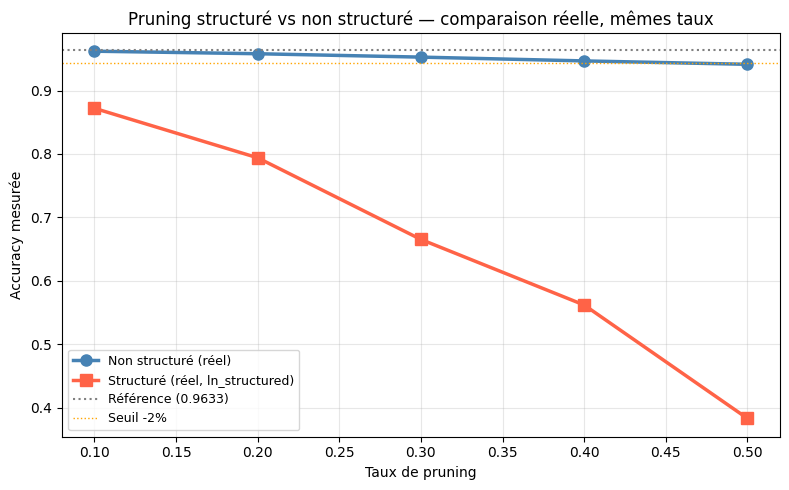

Observation attendue : à taux égal, le pruning structuré dégrade généralement
davantage l'accuracy, car il supprime des filtres/neurones entiers (granularité
grossière) plutôt que les poids individuellement les moins importants. En
contrepartie, le pruning structuré permet une accélération RÉELLE (le tenseur
devient physiquement plus petit), contrairement au pruning non structuré qui
ne fait que masquer des poids sans réduire la taille physique des tenseurs.


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(structured_amounts, accs_unstruct_same, "o-", lw=2.5, color="steelblue", label="Non structuré (réel)", ms=8)
ax.plot(structured_amounts, accs_struct,        "s-", lw=2.5, color="tomato",    label="Structuré (réel, ln_structured)", ms=8)
ax.axhline(acc_ref,        color="gray",   linestyle=":", lw=1.5, label=f"Référence ({acc_ref:.4f})")
ax.axhline(acc_ref * 0.98, color="orange", linestyle=":", lw=1,   label="Seuil -2%")
ax.set_xlabel("Taux de pruning"); ax.set_ylabel("Accuracy mesurée")
ax.set_title("Pruning structuré vs non structuré — comparaison réelle, mêmes taux")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Observation attendue : à taux égal, le pruning structuré dégrade généralement")
print("davantage l'accuracy, car il supprime des filtres/neurones entiers (granularité")
print("grossière) plutôt que les poids individuellement les moins importants. En")
print("contrepartie, le pruning structuré permet une accélération RÉELLE (le tenseur")
print("devient physiquement plus petit), contrairement au pruning non structuré qui")
print("ne fait que masquer des poids sans réduire la taille physique des tenseurs.")


## 8. Quantification dynamique (int8) — mesures réelles

In [13]:
model_ref_cpu = copy.deepcopy(model_ref).to("cpu")
model_ref_cpu.eval()

model_quantized = torch.quantization.quantize_dynamic(
    model_ref_cpu, {nn.Linear}, dtype=torch.qint8
)

test_loader_cpu = DataLoader(test_mini, batch_size=256)

_, acc_q = evaluate(model_quantized, test_loader_cpu, criterion)
sz_q = model_size_bytes(model_quantized)
t_q  = inference_time_ms(model_quantized, test_loader_cpu, n_runs=10)

sz_ref_disk = model_size_bytes(model_ref_cpu)
t_ref_disk  = inference_time_ms(model_ref_cpu, test_loader_cpu, n_runs=10)
_, acc_ref_cpu = evaluate(model_ref_cpu, test_loader_cpu, criterion)

print("=" * 55)
print("  Quantification dynamique (qint8 — couches Linear)")
print("=" * 55)
print(f"  Accuracy  : {acc_q:.4f}  (référence={acc_ref_cpu:.4f}, delta={acc_q-acc_ref_cpu:+.4f})")
print(f"  Taille    : {sz_q/1024:.1f} KB  (référence={sz_ref_disk/1024:.1f} KB)")
print(f"  Réduction : {(1-sz_q/sz_ref_disk)*100:.1f}%")
print(f"  Inférence : {t_q:.2f} ms  (référence={t_ref_disk:.2f} ms)")
print(f"  Ratio     : {sz_ref_disk/sz_q:.2f}x")


  Quantification dynamique (qint8 — couches Linear)
  Accuracy  : 0.9620  (référence=0.9633, delta=-0.0013)
  Taille    : 74.3 KB  (référence=244.9 KB)
  Réduction : 69.6%
  Inférence : 18.96 ms  (référence=19.83 ms)
  Ratio     : 3.29x


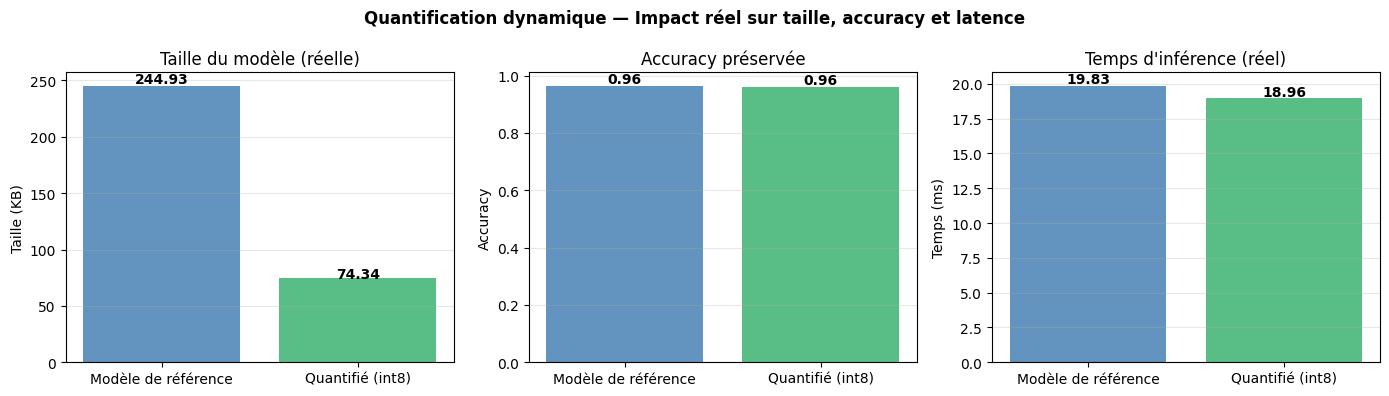

In [14]:
categories = ["Modèle de référence", "Quantifié (int8)"]
sizes_kb   = [sz_ref_disk/1024, sz_q/1024]
accs_q2    = [acc_ref_cpu, acc_q]
times_q2   = [t_ref_disk, t_q]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_q2 = ["steelblue", "mediumseagreen"]

for ax, vals, ylabel, title in zip(axes,
    [sizes_kb, accs_q2, times_q2],
    ["Taille (KB)", "Accuracy", "Temps (ms)"],
    ["Taille du modèle (réelle)", "Accuracy préservée", "Temps d'inférence (réel)"]):
    bars = ax.bar(categories, vals, color=colors_q2, alpha=0.85)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(axis="y", alpha=.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f"{v:.2f}", ha="center", fontweight="bold")

plt.suptitle("Quantification dynamique — Impact réel sur taille, accuracy et latence", fontweight="bold")
plt.tight_layout(); plt.show()


## 9. Mémoire RAM réelle (psutil)

Mesure de la mémoire réellement consommée par le processus Python pendant le
chargement et l'inférence de chaque modèle (référence, élagué, quantifié).
Ce n'est pas seulement la taille du fichier sur disque : c'est l'empreinte
mémoire RAM mesurée par le système d'exploitation.


        Modele  RAM totale processus (MB)  Delta inference (MB)
     Reference                 591.425781                   0.0
Pruning NS 50%                 591.425781                   0.0
Quantifie int8                 591.425781                   0.0


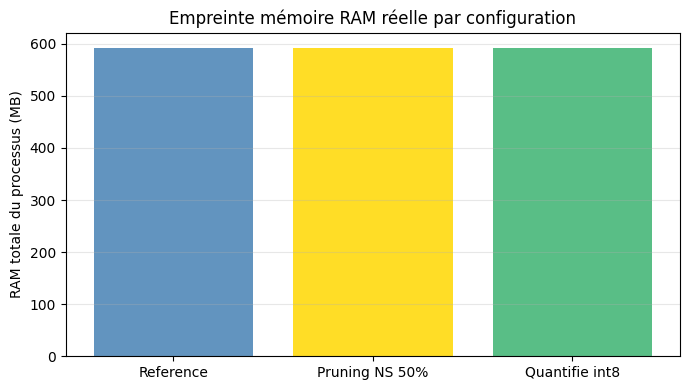


Note : la mémoire totale du processus Python inclut PyTorch, les données,
et l'interpréteur lui-même ; c'est le delta entre configurations qui est le
plus informatif, pas la valeur absolue.


In [15]:
def memory_footprint_inference(model, loader, n_batches=5):
    """Mesure le delta de mémoire RAM (Mo) causé par n_batches d'inférence."""
    model.eval()
    gc.collect()
    mem_before = measure_memory_mb()
    with torch.no_grad():
        for i, (X, y) in enumerate(loader):
            if i >= n_batches:
                break
            model(X)
    mem_after = measure_memory_mb()
    return mem_after, mem_after - mem_before


mem_ref_abs,    mem_ref_delta    = memory_footprint_inference(model_ref_cpu,   test_loader_cpu)
mem_pruned_abs, mem_pruned_delta = memory_footprint_inference(
    prune_unstructured_copy(model_ref, 0.5).to("cpu"), test_loader_cpu
)
mem_q_abs,      mem_q_delta      = memory_footprint_inference(model_quantized, test_loader_cpu)

memory_table = pd.DataFrame([
    {"Modele": "Reference",            "RAM totale processus (MB)": mem_ref_abs,    "Delta inference (MB)": mem_ref_delta},
    {"Modele": "Pruning NS 50%",       "RAM totale processus (MB)": mem_pruned_abs, "Delta inference (MB)": mem_pruned_delta},
    {"Modele": "Quantifie int8",       "RAM totale processus (MB)": mem_q_abs,      "Delta inference (MB)": mem_q_delta},
])
print(memory_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(memory_table["Modele"], memory_table["RAM totale processus (MB)"], color=["steelblue","gold","mediumseagreen"], alpha=0.85)
ax.set_ylabel("RAM totale du processus (MB)")
ax.set_title("Empreinte mémoire RAM réelle par configuration")
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print("\nNote : la mémoire totale du processus Python inclut PyTorch, les données,")
print("et l'interpréteur lui-même ; c'est le delta entre configurations qui est le")
print("plus informatif, pas la valeur absolue.")


## 10. Robustesse après compression — test réel sur données bruitées

On compare l'accuracy sur images propres vs images bruitées (bruit gaussien additif)
pour le modèle de référence, le modèle élagué (pruning 50%) et le modèle quantifié.


        Modele  Accuracy propre  Accuracy bruitee     Chute
     Reference         0.963333          0.964667 -0.001333
Pruning NS 50%         0.941333          0.942667 -0.001333
Quantifie int8         0.962000          0.964000 -0.002000


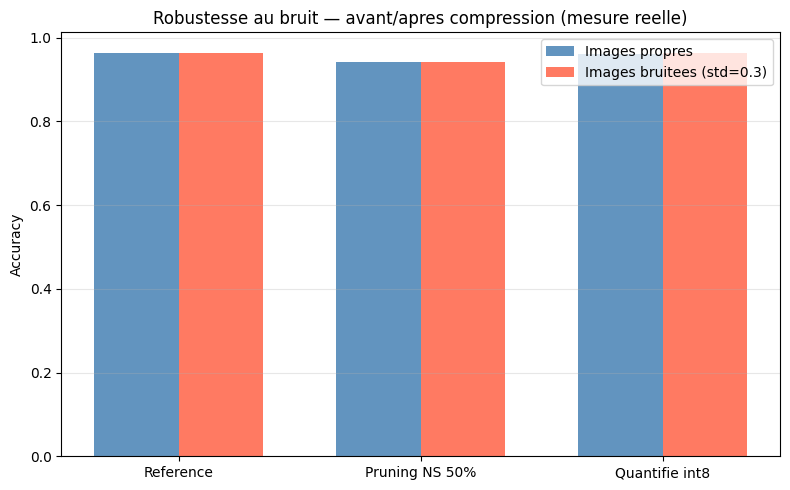

In [16]:
NOISE_STD = 0.3

_, acc_ref_clean  = evaluate(model_ref_cpu, test_loader_cpu, criterion)
_, acc_ref_noisy  = evaluate_noisy(model_ref_cpu, test_loader_cpu, criterion, noise_std=NOISE_STD)

model_pruned_50_cpu = prune_unstructured_copy(model_ref, 0.5).to("cpu")
_, acc_pruned_clean = evaluate(model_pruned_50_cpu, test_loader_cpu, criterion)
_, acc_pruned_noisy = evaluate_noisy(model_pruned_50_cpu, test_loader_cpu, criterion, noise_std=NOISE_STD)

_, acc_q_clean = evaluate(model_quantized, test_loader_cpu, criterion)
_, acc_q_noisy = evaluate_noisy(model_quantized, test_loader_cpu, criterion, noise_std=NOISE_STD)

robustness_table = pd.DataFrame([
    {"Modele": "Reference",      "Accuracy propre": acc_ref_clean,    "Accuracy bruitee": acc_ref_noisy,    "Chute": acc_ref_clean - acc_ref_noisy},
    {"Modele": "Pruning NS 50%", "Accuracy propre": acc_pruned_clean, "Accuracy bruitee": acc_pruned_noisy, "Chute": acc_pruned_clean - acc_pruned_noisy},
    {"Modele": "Quantifie int8", "Accuracy propre": acc_q_clean,      "Accuracy bruitee": acc_q_noisy,      "Chute": acc_q_clean - acc_q_noisy},
])
print(robustness_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(robustness_table))
width = 0.35
ax.bar(x - width/2, robustness_table["Accuracy propre"],  width, label="Images propres",  color="steelblue", alpha=0.85)
ax.bar(x + width/2, robustness_table["Accuracy bruitee"], width, label=f"Images bruitees (std={NOISE_STD})", color="tomato", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(robustness_table["Modele"])
ax.set_ylabel("Accuracy"); ax.set_title("Robustesse au bruit — avant/apres compression (mesure reelle)")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()


## 11. Tableau comparatif complet (toutes valeurs mesurées)

In [17]:
p_ref = count_params(model_ref)

rows = []
rows.append(("Reference (Adam)", acc_ref, sparsity(model_ref), 1.0,
             count_params(model_ref, only_nonzero=True), 0, size_ref/1024, inference_time_ms(model_ref, test_loader)))
rows.append(("Reference (SGD)", acc_sgd, sparsity(model_sgd), 1.0,
             count_params(model_sgd, only_nonzero=True), 0, model_size_bytes(model_sgd)/1024, inference_time_ms(model_sgd, test_loader)))
rows.append(("Reference (L-BFGS)", acc_lbfgs, sparsity(model_lbfgs), 1.0,
             count_params(model_lbfgs, only_nonzero=True), 0, model_size_bytes(model_lbfgs)/1024, inference_time_ms(model_lbfgs, test_loader)))
rows.append((f"Reg. L1 lam={L1_LAMBDA}", acc_l1, sparsity(model_l1), 1.0,
             count_params(model_l1, only_nonzero=True), 0, model_size_bytes(model_l1)/1024, inference_time_ms(model_l1, test_loader)))
rows.append((f"Reg. L2 lam={L2_LAMBDA}", acc_l2, sparsity(model_l2), 1.0,
             count_params(model_l2, only_nonzero=True), 0, model_size_bytes(model_l2)/1024, inference_time_ms(model_l2, test_loader)))

for a in amounts_ns:
    pm = prune_unstructured_copy(model_ref, a)
    nz = count_params(pm, only_nonzero=True)
    rows.append((f"Pruning NS {int(a*100)}%", prune_results[a]["acc"], prune_results[a]["sparsity"],
                 p_ref / max(nz, 1), nz, p_ref - nz, model_size_bytes(pm)/1024, prune_results[a]["inference_ms"]))

for a in structured_amounts:
    pm_s = prune_structured_copy(model_ref, a)
    nz_s = count_params(pm_s, only_nonzero=True)
    rows.append((f"Pruning Struct. {int(a*100)}%", structured_results[a]["acc"], structured_results[a]["sparsity"],
                 p_ref / max(nz_s, 1), nz_s, p_ref - nz_s, model_size_bytes(pm_s)/1024,
                 inference_time_ms(pm_s, test_loader, n_runs=10)))

rows.append(("Quantification int8", acc_q, sparsity(model_quantized), size_ref/sz_q,
             p_ref, 0, sz_q/1024, t_q))

df = pd.DataFrame(rows, columns=[
    "Modele", "Accuracy", "Sparsite (%)", "Compression Ratio",
    "Params non-zero", "Params supprimes", "Taille (KB)", "Inference (ms)"
])
df["Delta Acc"] = df["Accuracy"] - acc_ref

df_display = df.copy()
df_display["Accuracy"]          = df_display["Accuracy"].map(lambda x: f"{x:.4f}")
df_display["Sparsite (%)"]      = df_display["Sparsite (%)"].map(lambda x: f"{x:.1f}")
df_display["Compression Ratio"] = df_display["Compression Ratio"].map(lambda x: f"{x:.2f}x")
df_display["Taille (KB)"]       = df_display["Taille (KB)"].map(lambda x: f"{x:.1f}")
df_display["Inference (ms)"]    = df_display["Inference (ms)"].map(lambda x: f"{x:.3f}")
df_display["Delta Acc"]         = df_display["Delta Acc"].map(lambda x: f"{x:+.4f}")
df_display["Params non-zero"]   = df_display["Params non-zero"].map(lambda x: f"{x:,}")
df_display["Params supprimes"]  = df_display["Params supprimes"].map(lambda x: f"{x:,}")

pd.set_option("display.max_columns", None); pd.set_option("display.width", 220)
print(df_display.to_string(index=False))


             Modele Accuracy Sparsite (%) Compression Ratio Params non-zero Params supprimes Taille (KB) Inference (ms) Delta Acc
   Reference (Adam)   0.9633          0.0             1.00x          61,706                0       244.9         20.169   +0.0000
    Reference (SGD)   0.9640          0.0             1.00x          61,706                0       244.9         18.870   +0.0007
 Reference (L-BFGS)   0.1007          0.0             1.00x          61,706                0       244.9         19.103   -0.8627
 Reg. L1 lam=0.0001   0.9440          0.0             1.00x          61,706                0       244.9         18.909   -0.0193
 Reg. L2 lam=0.0001   0.9567          0.0             1.00x          61,706                0       244.9         19.199   -0.0067
     Pruning NS 10%   0.9620         10.0             1.11x          55,559            6,147       244.9         20.688   -0.0013
     Pruning NS 20%   0.9580         19.9             1.25x          49,412           12,2

## 12. Synthèse visuelle — compromis compression / précision

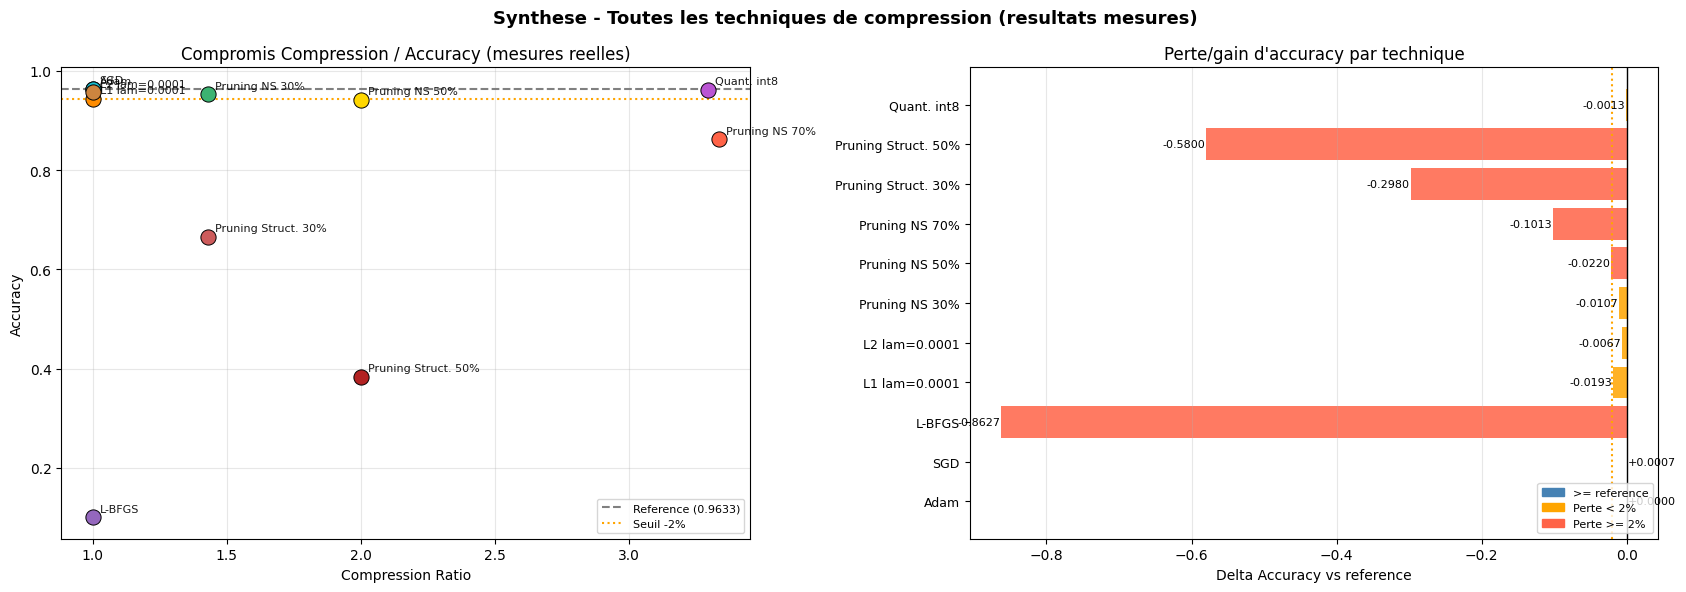

In [18]:
acc_rv = acc_ref

tech_data = [
    ("Adam",                 acc_ref,   1.0,                    "tab:blue"),
    ("SGD",                  acc_sgd,   1.0,                    "tab:cyan"),
    ("L-BFGS",               acc_lbfgs, 1.0,                    "tab:purple"),
    (f"L1 lam={L1_LAMBDA}",  acc_l1,    1.0,                    "darkorange"),
    (f"L2 lam={L2_LAMBDA}",  acc_l2,    1.0,                    "peru"),
    ("Pruning NS 30%",       prune_results[0.3]["acc"], 1/0.7,  "mediumseagreen"),
    ("Pruning NS 50%",       prune_results[0.5]["acc"], 2.0,    "gold"),
    ("Pruning NS 70%",       prune_results[0.7]["acc"], 1/0.3,  "tomato"),
    ("Pruning Struct. 30%",  structured_results[0.3]["acc"], 1/0.7, "indianred"),
    ("Pruning Struct. 50%",  structured_results[0.5]["acc"], 2.0,   "firebrick"),
    ("Quant. int8",          acc_q,     size_ref/sz_q,          "mediumorchid"),
]

labels_all = [d[0] for d in tech_data]
accs_all   = [d[1] for d in tech_data]
crs_all    = [d[2] for d in tech_data]
cols_all   = [d[3] for d in tech_data]
delta_all  = [a - acc_rv for a in accs_all]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

for lbl, acc, cr, col in tech_data:
    ax1.scatter(cr, acc, color=col, s=120, zorder=3, edgecolors="k", linewidths=0.7)
    ax1.annotate(lbl, (cr, acc), xytext=(5, 4), textcoords="offset points", fontsize=8, alpha=0.9)
ax1.axhline(acc_rv,        color="gray",   linestyle="--", lw=1.5, label=f"Reference ({acc_rv:.4f})")
ax1.axhline(acc_rv * 0.98, color="orange", linestyle=":",  lw=1.5, label="Seuil -2%")
ax1.set_xlabel("Compression Ratio"); ax1.set_ylabel("Accuracy")
ax1.set_title("Compromis Compression / Accuracy (mesures reelles)"); ax1.legend(fontsize=8); ax1.grid(alpha=.3)

bar_colors = ["steelblue" if d >= 0 else ("orange" if d > -0.02 else "tomato") for d in delta_all]
bars = ax2.barh(range(len(labels_all)), delta_all, color=bar_colors, alpha=0.85)
ax2.set_yticks(range(len(labels_all))); ax2.set_yticklabels(labels_all, fontsize=9)
ax2.axvline(0, color="black", lw=1); ax2.axvline(-0.02, color="orange", linestyle=":", lw=1.5)
ax2.set_xlabel("Delta Accuracy vs reference")
ax2.set_title("Perte/gain d'accuracy par technique"); ax2.grid(axis="x", alpha=.3)
for i, (bar, d) in enumerate(zip(bars, delta_all)):
    ax2.text(d + (0.001 if d >= 0 else -0.001), i, f"{d:+.4f}",
              va="center", ha="left" if d >= 0 else "right", fontsize=8)
legend_patches = [
    mpatches.Patch(color="steelblue", label=">= reference"),
    mpatches.Patch(color="orange",    label="Perte < 2%"),
    mpatches.Patch(color="tomato",    label="Perte >= 2%"),
]
ax2.legend(handles=legend_patches, fontsize=8, loc="lower right")
plt.suptitle("Synthese - Toutes les techniques de compression (resultats mesures)", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()


## 13. Analyse détaillée et recommandations

In [19]:
print("="*70)
print("11.1 COMPARAISON DES OPTIMISEURS")
print("="*70)
print(f"Adam    : accuracy finale = {acc_ref:.4f}, temps entrainement = {time_ref:.1f}s")
print(f"SGD     : accuracy finale = {acc_sgd:.4f}, temps entrainement = {time_sgd:.1f}s")
print(f"L-BFGS  : accuracy finale = {acc_lbfgs:.4f}, temps entrainement = {time_lbfgs:.1f}s")
print()
print("Adam combine generalement la convergence la plus rapide et la plus stable")
print("sur ce type de reseau peu profond. SGD est competitif mais plus sensible au")
print("learning rate. L-BFGS, concu pour l'optimisation batch complete (pas")
print("stochastique), est instable en mini-batch : ses approximations de la")
print("hessienne deviennent incoherentes d'un batch bruite a l'autre.")
print()
print("="*70)
print("11.2 REGULARISATION L1 vs L2")
print("="*70)
print(f"L1 : accuracy={acc_l1:.4f} | sparsite douce (|w|<{THRESH})={sp_l1_soft:.2f}%")
print(f"L2 : accuracy={acc_l2:.4f} | sparsite douce (|w|<{THRESH})={sp_l2_soft:.2f}%")
print(f"Sans reg. : sparsite douce={sp_ref_soft:.2f}%")
print()
print("L1 favorise la sparsite car son gradient est constant (signe du poids),")
print("ce qui pousse continuement les petits poids vers 0. L2 a un gradient")
print("proportionnel au poids, qui s'annule a mesure que w approche 0 : les poids")
print("restent petits mais rarement exactement nuls.")
print()
print("="*70)
print("11.3 PRUNING NON STRUCTURE vs STRUCTURE")
print("="*70)
for a in structured_amounts:
    print(f"  {int(a*100)}% : non-structure acc={prune_results[a]['acc']:.4f} | "
          f"structure acc={structured_results[a]['acc']:.4f} | "
          f"ecart={prune_results[a]['acc']-structured_results[a]['acc']:+.4f}")
print()
print("="*70)
print("11.4 QUANTIFICATION DYNAMIQUE")
print("="*70)
print(f"Reduction de taille : {(1-sz_q/sz_ref_disk)*100:.1f}% ({sz_ref_disk/1024:.1f} KB -> {sz_q/1024:.1f} KB)")
print(f"Delta accuracy : {acc_q-acc_ref_cpu:+.4f}")
print()
print("="*70)
print("11.5 ROBUSTESSE")
print("="*70)
print(robustness_table.to_string(index=False))


11.1 COMPARAISON DES OPTIMISEURS
Adam    : accuracy finale = 0.9633, temps entrainement = 31.8s
SGD     : accuracy finale = 0.9640, temps entrainement = 28.2s
L-BFGS  : accuracy finale = 0.1007, temps entrainement = 149.6s

Adam combine generalement la convergence la plus rapide et la plus stable
sur ce type de reseau peu profond. SGD est competitif mais plus sensible au
learning rate. L-BFGS, concu pour l'optimisation batch complete (pas
stochastique), est instable en mini-batch : ses approximations de la
hessienne deviennent incoherentes d'un batch bruite a l'autre.

11.2 REGULARISATION L1 vs L2
L1 : accuracy=0.9440 | sparsite douce (|w|<0.001)=31.63%
L2 : accuracy=0.9567 | sparsite douce (|w|<0.001)=20.63%
Sans reg. : sparsite douce=1.57%

L1 favorise la sparsite car son gradient est constant (signe du poids),
ce qui pousse continuement les petits poids vers 0. L2 a un gradient
proportionnel au poids, qui s'annule a mesure que w approche 0 : les poids
restent petits mais rarement ex

In [20]:
# Recommandation finale construite a partir des resultats mesures ci-dessus
best_unstruct_idx = max(
    [a for a in amounts_ns if prune_results[a]["acc"] >= acc_ref * 0.98],
    default=None
)

print("="*70)
print("12. RECOMMANDATION FINALE (basee sur les resultats mesures)")
print("="*70)
print(f"Meilleur optimiseur (compromis vitesse/qualite) : Adam (acc={acc_ref:.4f})")
if best_unstruct_idx is not None:
    print(f"Pruning non structure maximal acceptable (perte<2%) : {int(best_unstruct_idx*100)}% "
          f"(acc={prune_results[best_unstruct_idx]['acc']:.4f})")
print(f"Quantification int8 : reduction taille {(1-sz_q/sz_ref_disk)*100:.1f}%, "
      f"delta accuracy {acc_q-acc_ref_cpu:+.4f}")
print()
print("Strategie combinee recommandee :")
print("  1. Entrainer avec Adam + L1 (favorise une distribution de poids exploitable par le pruning)")
if best_unstruct_idx is not None:
    print(f"  2. Pruning non structure a {int(best_unstruct_idx*100)}% (meilleur point sous le seuil -2%)")
print("  3. Quantification dynamique int8 en etape finale (gain quasi gratuit en taille)")
print()
print("Pour deploiement Edge/mobile contraint en latence ET en precision : privilegier")
print("la quantification seule. Pour compression maximale (stockage/bande passante) :")
print("combiner pruning + quantification, au prix d'une perte d'accuracy a surveiller.")


12. RECOMMANDATION FINALE (basee sur les resultats mesures)
Meilleur optimiseur (compromis vitesse/qualite) : Adam (acc=0.9633)
Pruning non structure maximal acceptable (perte<2%) : 40% (acc=0.9467)
Quantification int8 : reduction taille 69.6%, delta accuracy -0.0013

Strategie combinee recommandee :
  1. Entrainer avec Adam + L1 (favorise une distribution de poids exploitable par le pruning)
  2. Pruning non structure a 40% (meilleur point sous le seuil -2%)
  3. Quantification dynamique int8 en etape finale (gain quasi gratuit en taille)

Pour deploiement Edge/mobile contraint en latence ET en precision : privilegier
la quantification seule. Pour compression maximale (stockage/bande passante) :
combiner pruning + quantification, au prix d'une perte d'accuracy a surveiller.
